# Predicting Vehicle Prices Using Regression Models

## Problem Statement
A used car reseller needs accurate price predictions to stay competitive and maximise
profitability. Using listing data from AutoScout (a German online car trading platform),
we build and compare regression models to predict car prices based on vehicle specs,
condition, and features.

## Objectives
- Predict used car prices from 15,915 listings across 23 features
- Identify the most influential factors driving car prices
- Apply Ridge and Lasso regularisation to prevent overfitting and understand
  how penalisation affects model behaviour

## Pipeline
1. Data Loading & Understanding
2. EDA & Preprocessing distributions, missing values, rare categories, outliers
3. Feature Engineering for encoding, splitting, scaling
4. Baseline Linear Regression to establish benchmark performance
5. Ridge Regression L2 regularisation, alpha tuning
6. Lasso Regression L1 regularisation, feature selection via alpha tuning
7. Model Comparison & Conclusion


#####My first fine tuning Lets gooo!!!

In [17]:
# Importing necessary libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [18]:
## 1. Data Loading & Understanding
df = pd.read_csv('Car_Price_data.csv')

print(f'Shape: {df.shape}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 3 rows:')
df.head(3)

Shape: (15915, 23)

Data types:
make_model              object
body_type               object
price                    int64
vat                     object
km                     float64
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Extras                  object
Safety_Security         object
age                    float64
Previous_Owners        float64
hp_kW                  float64
Inspection_new           int64
Paint_Type              object
Upholstery_type         object
Gearing_Type            object
Displacement_cc        float64
Weight_kg              float64
Drive_chain             object
cons_comb              float64
dtype: object

First 3 rows:


,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8


In [19]:
# 1.1 Missing values and basic stats
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'\nNumerical summary:')
df.describe().round(2)

Missing values:
make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type             0
Upholstery_type        0
Gearing_Type           0
Displacement_cc        0
Weight_kg              0
Drive_chain            0
cons_comb              0
dtype: int64

Total missing: 0

Numerical summary:


,price,km,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
count,15915.00,15915.00,15915.00,15915.00,15915.00,15915.00,15915.00,15915.00,15915.00,15915.00
mean,18024.38,32090.00,5.94,1.39,1.04,88.50,0.25,1428.66,1337.70,4.83
std,7381.68,36977.21,0.70,1.12,0.34,26.67,0.43,275.80,199.68,0.87
min,4950.00,0.00,5.00,0.00,0.00,40.00,0.00,890.00,840.00,3.00
25%,12850.00,1920.50,5.00,0.00,1.00,66.00,0.00,1229.00,1165.00,4.10
50%,16900.00,20413.00,6.00,1.00,1.00,85.00,0.00,1461.00,1295.00,4.80
75%,21900.00,46900.00,6.00,2.00,1.00,103.00,0.00,1598.00,1472.00,5.40
max,74600.00,317000.00,8.00,3.00,4.00,294.00,1.00,2967.00,2471.00,9.10


In [20]:
# 1.2 Categorical col unique values
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Excluding the feature-list cols for now
simple_cats = [c for c in cat_cols if c not in
               ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']]

for col in simple_cats:
    print(f'{col} ({df[col].nunique()} unique):')
    print(df[col].value_counts().to_string())
    print()

make_model (9 unique):
make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1

body_type (8 unique):
body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8

vat (2 unique):
vat
VAT deductible      15044
Price negotiable      871

Type (5 unique):
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796

Fuel (4 unique):
Fuel
Benzine     8548
Diesel      7298
LPG/CNG       64
Electric       5

Paint_Type (3 unique):
Paint_Type
Metallic       15246
Uni/basic        637
Perl effect       32

Upholstery_type (2 unique):
Upholstery_type
Cloth                12234
Part/Full Leather     3681

Gearing_Type (3 unique):
Gearing_Type
Manual 

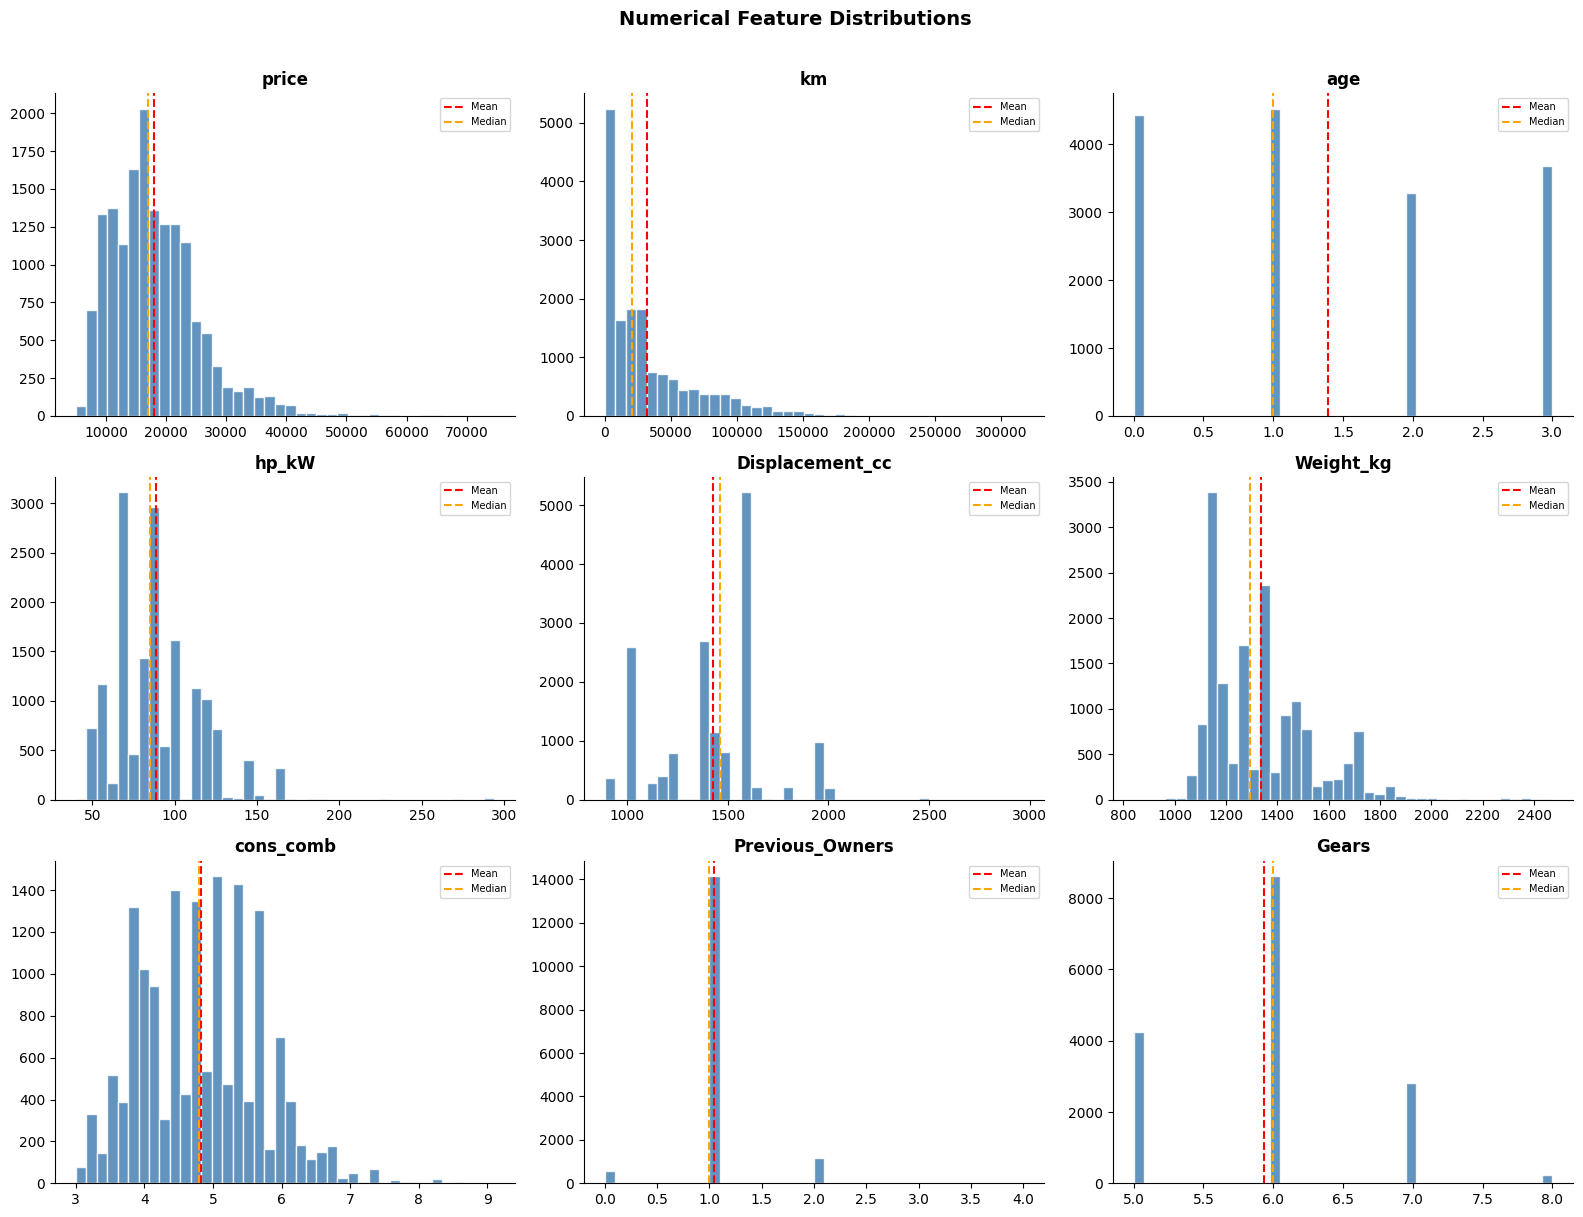

In [12]:
## 2. EDA n Preprocessing

# 2.1 Numerical feature distributions
num_cols = ['price', 'km', 'age', 'hp_kW', 'Displacement_cc',
            'Weight_kg', 'cons_comb', 'Previous_Owners', 'Gears']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

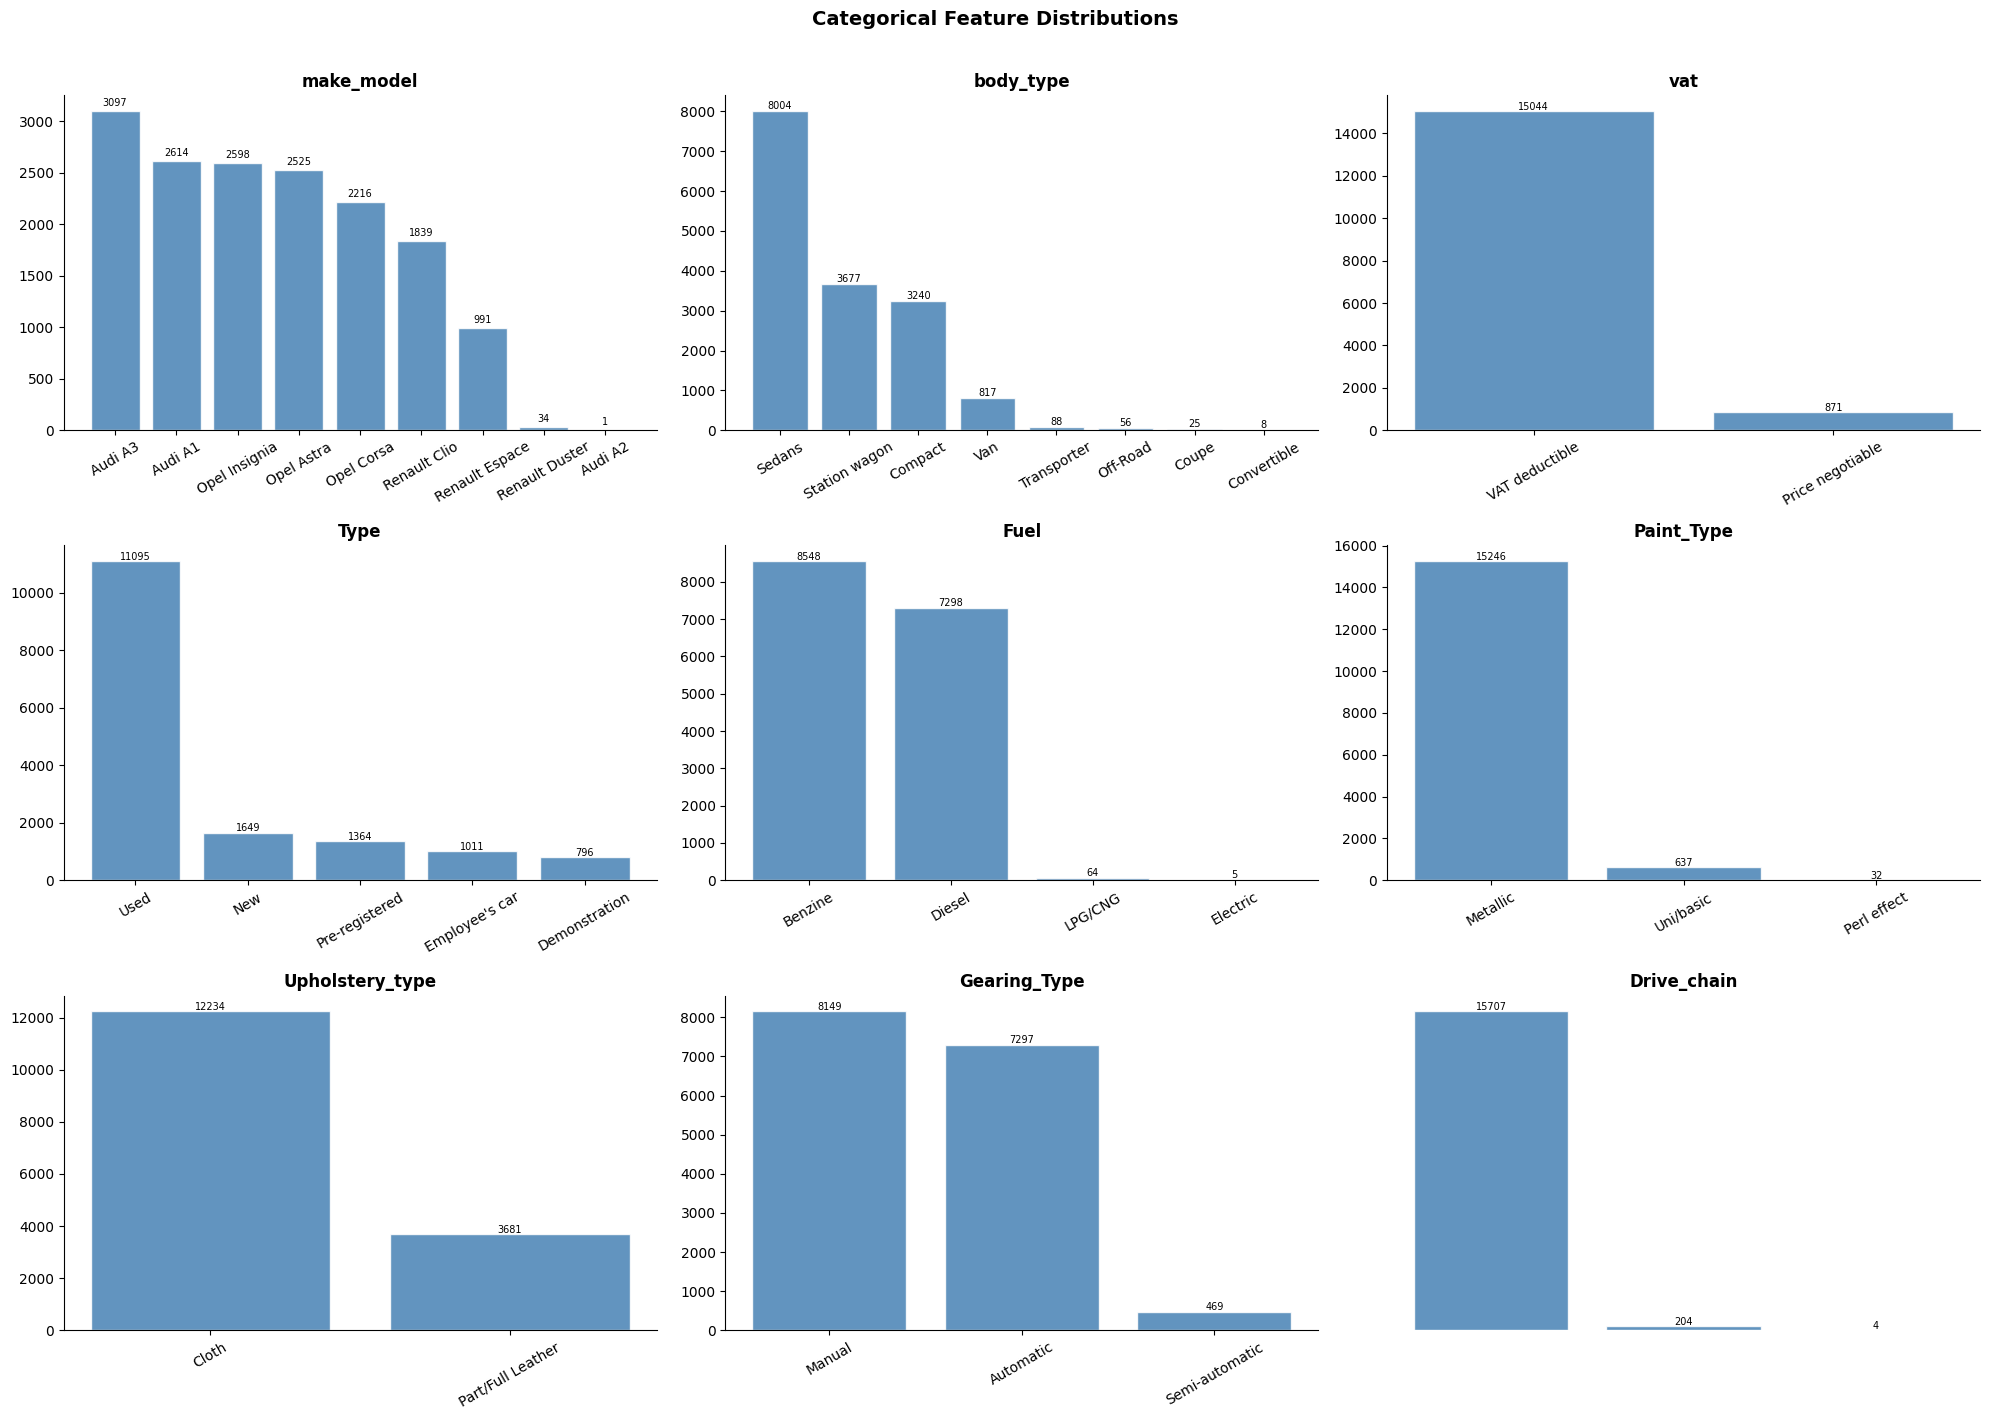

In [13]:
# 2.2 Categorical feature distributions
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(simple_cats):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', alpha=0.85, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 50, str(v), ha='center', fontsize=7)

axes[-1].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# 2.3 Fix rare categories and inconsistecies

# Drop Audi A2 as only 1 row, not useful
df = df[df['make_model'] != 'Audi A2'].reset_index(drop=True)

# body_type we need to group rare types as 'Other'
df['body_type'] = df['body_type'].replace(
    {'Transporter': 'Other', 'Off-Road': 'Other', 'Coupe': 'Other', 'Convertible': 'Other'}
)

# Type: Pre-registered, Employee's car, Demonstration are all new-like vehicles
df['Type'] = df['Type'].replace(
    {'Pre-registered': 'New', "Employee's car": 'New', 'Demonstration': 'New'}
)

# Fuel LPG/CNG and Electric are too rare to model separately
df['Fuel'] = df['Fuel'].replace({'LPG/CNG': 'Other', 'Electric': 'Other'})

# Paint_Type Perl effect is rare, group with Uni/basic
df['Paint_Type'] = df['Paint_Type'].replace({'Perl effect': 'Uni/basic'})

# Drive_chain rear only 4 rows, group with 4WD
df['Drive_chain'] = df['Drive_chain'].replace({'rear': 'Other', '4WD': 'Other'})

print(f'Shape after cleaning: {df.shape}')
print(f"\nType:\n{df['Type'].value_counts()}")
print(f"\nFuel:\n{df['Fuel'].value_counts()}")
print(f"\nbody_type:\n{df['body_type'].value_counts()}")

Shape after cleaning: (15914, 23)

Type:
Type
Used    11095
New      4819
Name: count, dtype: int64

Fuel:
Fuel
Benzine    8548
Diesel     7297
Other        69
Name: count, dtype: int64

body_type:
body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Other             176
Name: count, dtype: int64


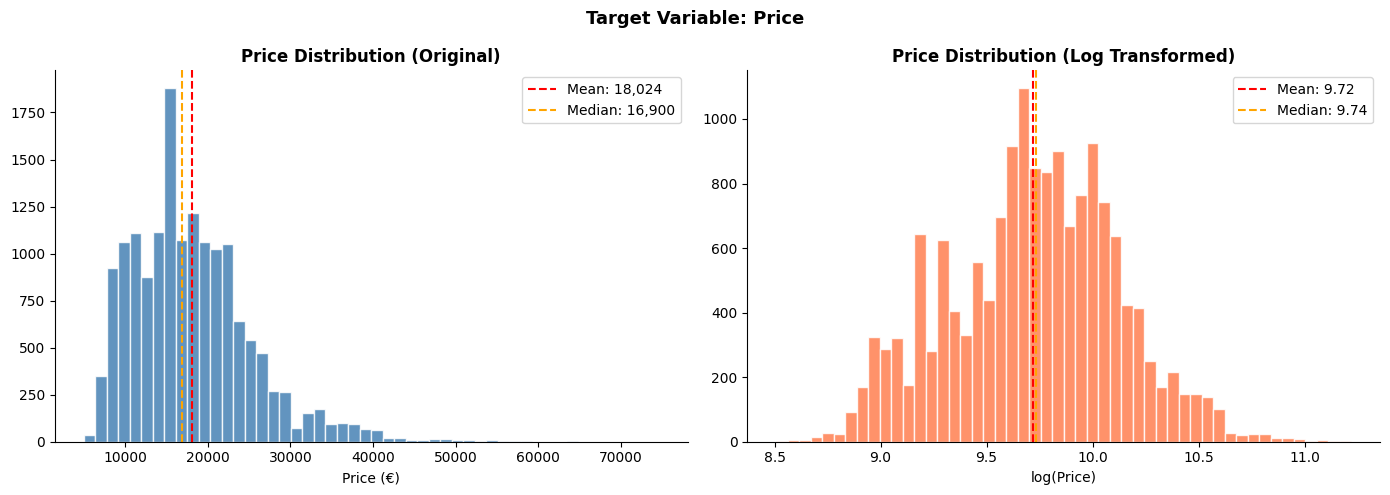

Original skewness : 1.236
Log skewness      : -0.031


In [15]:
# 2.4 Target variable price distribution and log transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original price
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['price'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["price"].median():,.0f}')
axes[0].set_title('Price Distribution (Original)', fontweight='bold')
axes[0].set_xlabel('Price (€)')
axes[0].legend()

# Log-transformed price
df['log_price'] = np.log(df['price'])
axes[1].hist(df['log_price'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(df['log_price'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df["log_price"].mean():.2f}')
axes[1].axvline(df['log_price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["log_price"].median():.2f}')
axes[1].set_title('Price Distribution (Log Transformed)', fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].legend()

plt.suptitle('Target Variable: Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Original skewness : {df["price"].skew():.3f}')
print(f'Log skewness      : {df["log_price"].skew():.3f}')

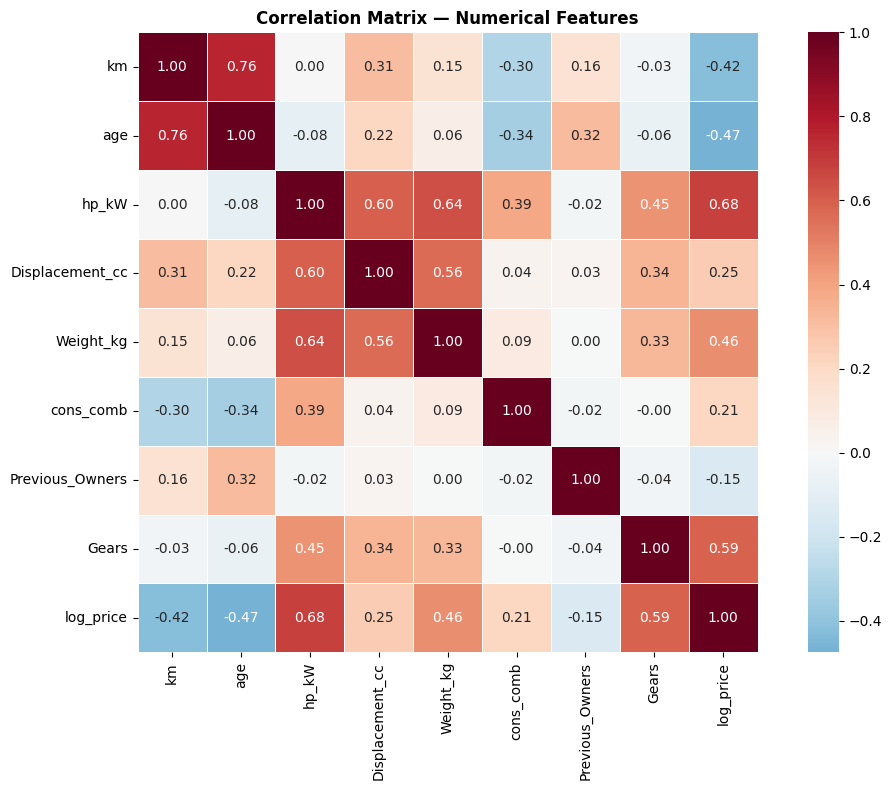

In [16]:
# 2.5 Correlation heatmap for numerical features vs log_price
num_cols = ['km', 'age', 'hp_kW', 'Displacement_cc', 'Weight_kg',
            'cons_comb', 'Previous_Owners', 'Gears', 'log_price']

plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

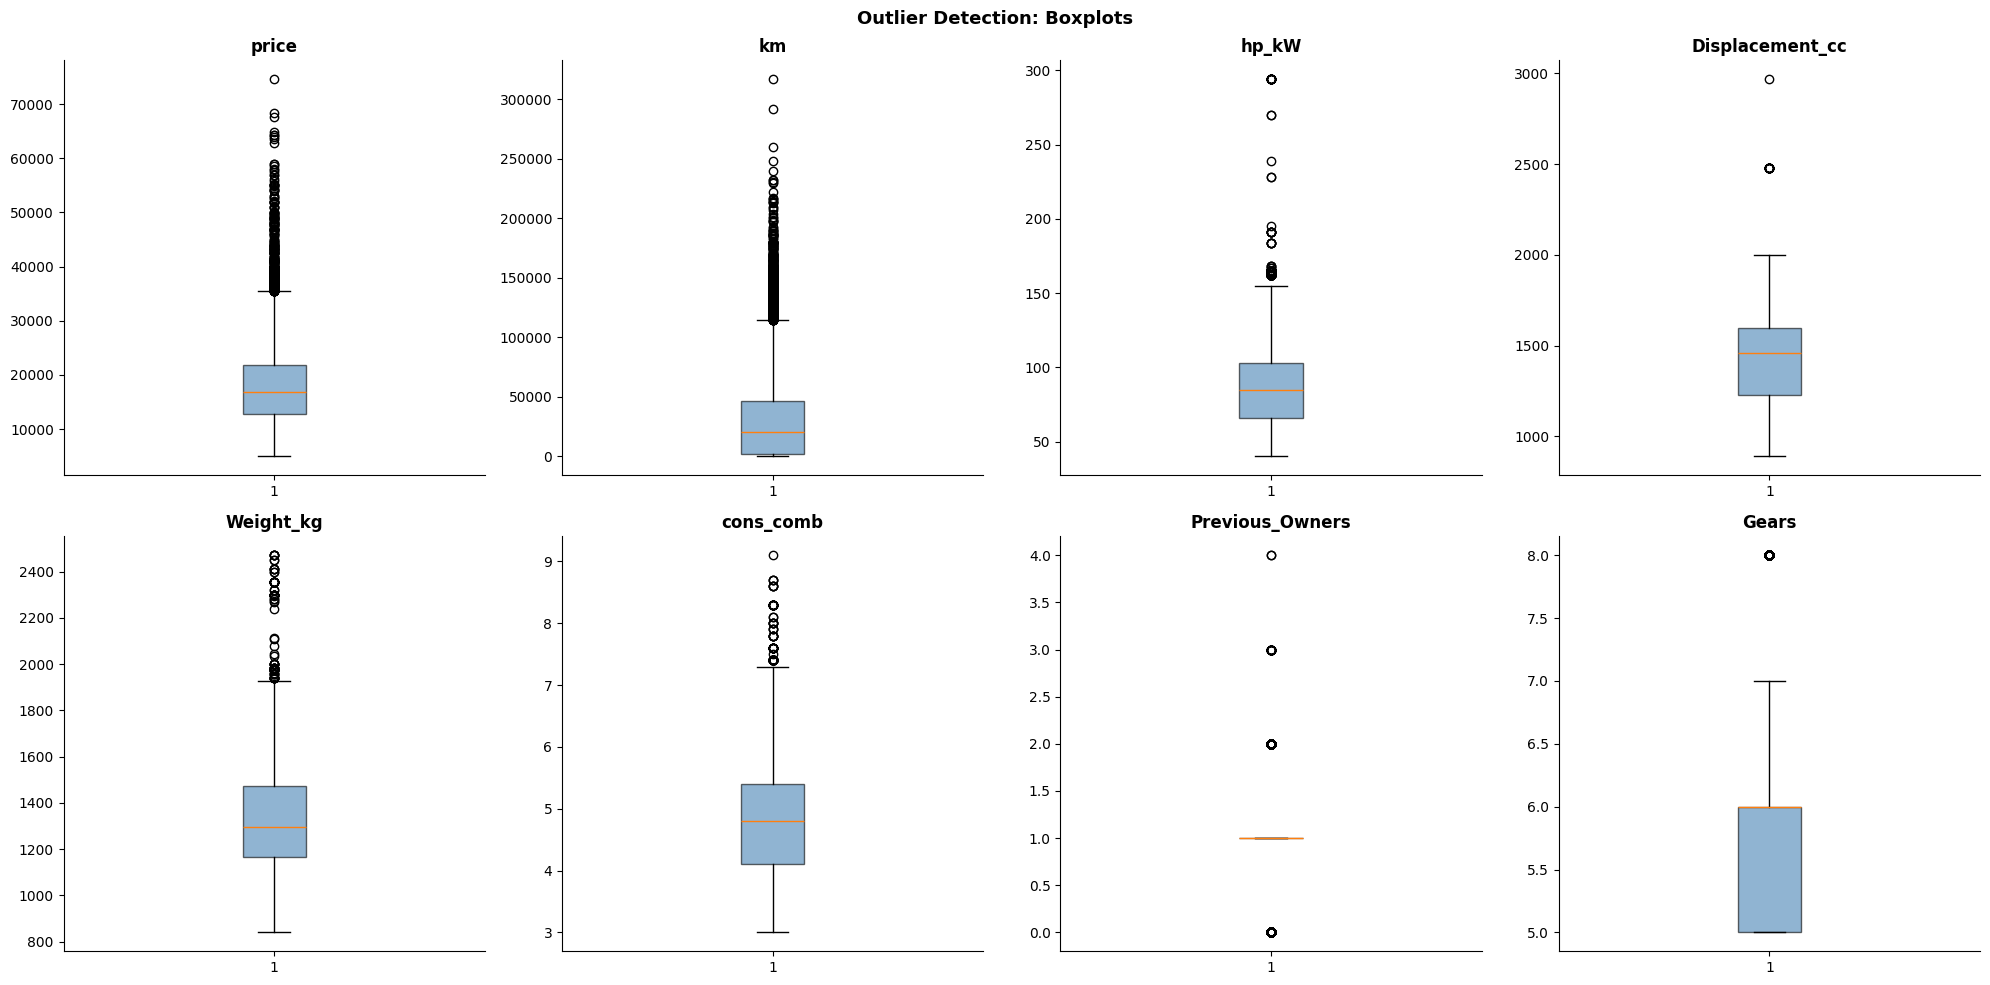

Outlier counts (IQR method):
  price               : 479
  km                  : 689
  hp_kW               : 361
  Displacement_cc     : 21
  Weight_kg           : 87
  cons_comb           : 125
  Previous_Owners     : 1757
  Gears               : 225


In [22]:
# 2.6 Outlier detection using boxplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

outlier_cols = ['price', 'km', 'hp_kW', 'Displacement_cc',
                'Weight_kg', 'cons_comb', 'Previous_Owners', 'Gears']

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Outlier Detection: Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print outlier counts using IQR method
print('Outlier counts (IQR method):')
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<20}: {outliers}')

In [23]:
# 2.7 Handle outliers winsorize using IQR bounds
# Previous_Owners excluded discrete 0-4, not truly extreme
winsor_cols = ['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'Gears']

for col in winsor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

# Price outliers handled indirectly via log transform lets skip raw price
print('Outlier counts after winsoriztion:')
for col in winsor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<20}: {outliers}')

print(f'\nShape: {df.shape}')

Outlier counts after winsoriztion:
  km                  : 0
  hp_kW               : 0
  Displacement_cc     : 0
  Weight_kg           : 0
  cons_comb           : 0
  Gears               : 0

Shape: (15915, 23)


In [24]:
print(df['make_model'].value_counts())

make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64


In [25]:
# Re-apply all cleaning fixes
df = df[df['make_model'] != 'Audi A2'].reset_index(drop=True)

df['body_type'] = df['body_type'].replace(
    {'Transporter': 'Other', 'Off-Road': 'Other', 'Coupe': 'Other', 'Convertible': 'Other'}
)
df['Type'] = df['Type'].replace(
    {'Pre-registered': 'New', "Employee's car": 'New', 'Demonstration': 'New'}
)
df['Fuel'] = df['Fuel'].replace({'LPG/CNG': 'Other', 'Electric': 'Other'})
df['Paint_Type'] = df['Paint_Type'].replace({'Perl effect': 'Uni/basic'})
df['Drive_chain'] = df['Drive_chain'].replace({'rear': 'Other', '4WD': 'Other'})

# Log transform target
df['log_price'] = np.log(df['price'])

# Winsorize outliers
winsor_cols = ['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'Gears']
for col in winsor_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(f'Shape: {df.shape}')
print(f"make_model unique: {df['make_model'].nunique()}")
print(f"Type values: {df['Type'].unique()}")
print(f"Fuel values: {df['Fuel'].unique()}")

Shape: (15914, 24)
make_model unique: 8
Type values: ['Used' 'New']
Fuel values: ['Diesel' 'Benzine' 'Other']


In [26]:
## 3. Feature Engineering

# 3.1 Convert feature-list columns to feature counts


list_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

for col in list_cols:
    count_col = col + '_count'
    df[count_col] = df[col].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

print('Feature counts summary:')
print(df[['Comfort_Convenience_count', 'Entertainment_Media_count',
          'Extras_count', 'Safety_Security_count']].describe().round(2))

# Drop the original string columns not usable by the model
df = df.drop(columns=list_cols)
print(f'\nShape after dropping list columns: {df.shape}')

Feature counts summary:
       Comfort_Convenience_count  Entertainment_Media_count  Extras_count  \
count                   15914.00                   15914.00      15914.00   
mean                       12.19                       4.67          2.24   
std                         6.05                       2.00          1.50   
min                         1.00                       1.00          1.00   
25%                         7.00                       3.00          1.00   
50%                        13.00                       5.00          2.00   
75%                        17.00                       6.00          3.00   
max                        33.00                      10.00         10.00   

       Safety_Security_count  
count               15914.00  
mean                   12.79  
std                     4.07  
min                     1.00  
25%                    11.00  
50%                    13.00  
75%                    15.00  
max                    29.00  

Sh

In [27]:
# 3.2 One-hot encode categorical columns
encode_cols = ['make_model', 'body_type', 'vat', 'Type', 'Fuel',
               'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

df_encoded = pd.get_dummies(df, columns=encode_cols, drop_first=True)

# Convert booleans to int
bool_cols = df_encoded.select_dtypes('bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'Columns: {df_encoded.columns.tolist()}')

Shape after encoding: (15914, 35)
Columns: ['price', 'km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb', 'log_price', 'Comfort_Convenience_count', 'Entertainment_Media_count', 'Extras_count', 'Safety_Security_count', 'make_model_Audi A3', 'make_model_Opel Astra', 'make_model_Opel Corsa', 'make_model_Opel Insignia', 'make_model_Renault Clio', 'make_model_Renault Duster', 'make_model_Renault Espace', 'body_type_Other', 'body_type_Sedans', 'body_type_Station wagon', 'body_type_Van', 'vat_VAT deductible', 'Type_Used', 'Fuel_Diesel', 'Fuel_Other', 'Paint_Type_Uni/basic', 'Upholstery_type_Part/Full Leather', 'Gearing_Type_Manual', 'Gearing_Type_Semi-automatic', 'Drive_chain_front']


In [28]:
# 3.3 Train/test split
# Drop original price as we predict log_price
X = df_encoded.drop(columns=['price', 'log_price'])
y = df_encoded['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3.4 Feature scaling to fit on train only to prevent data leakge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'\nTrain log_price mean: {y_train.mean():.4f}')
print(f'Test  log_price mean: {y_test.mean():.4f}')

X_train: (12731, 33)
X_test : (3183, 33)

Train log_price mean: 9.7222
Test  log_price mean: 9.7144


In [29]:
## 4. Baseline Linear Regression

# 4.1 Train baseline model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

# 4.2 Evaluate
def evaluate(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'{label}')
    print(f'  R²   : {r2:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    return r2, rmse, mae

print('Baseline Linear Regression')
print('=' * 35)
train_r2, train_rmse, train_mae = evaluate(y_train, y_pred_train, 'Train')
print()
test_r2,  test_rmse,  test_mae  = evaluate(y_test,  y_pred_test,  'Test')
print()
print(f'R² gap (overfit check): {train_r2 - test_r2:.4f}')

Baseline Linear Regression
Train
  R²   : 0.9181
  RMSE : 0.1139
  MAE  : 0.0849

Test
  R²   : 0.9177
  RMSE : 0.1144
  MAE  : 0.0854

R² gap (overfit check): 0.0004


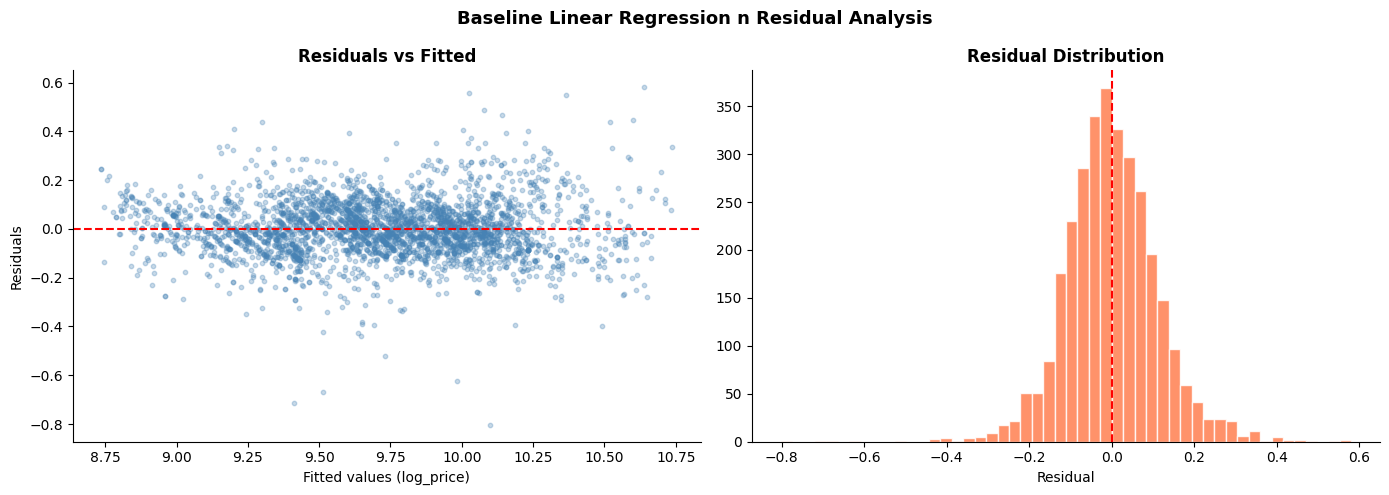

Residual mean : -0.000147
Residual std  : 0.1145


In [30]:
# 4.3 Residual analysis
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted
axes[0].scatter(y_pred_test, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted values (log_price)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Baseline Linear Regression n Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual mean : {residuals.mean():.6f}')
print(f'Residual std  : {residuals.std():.4f}')

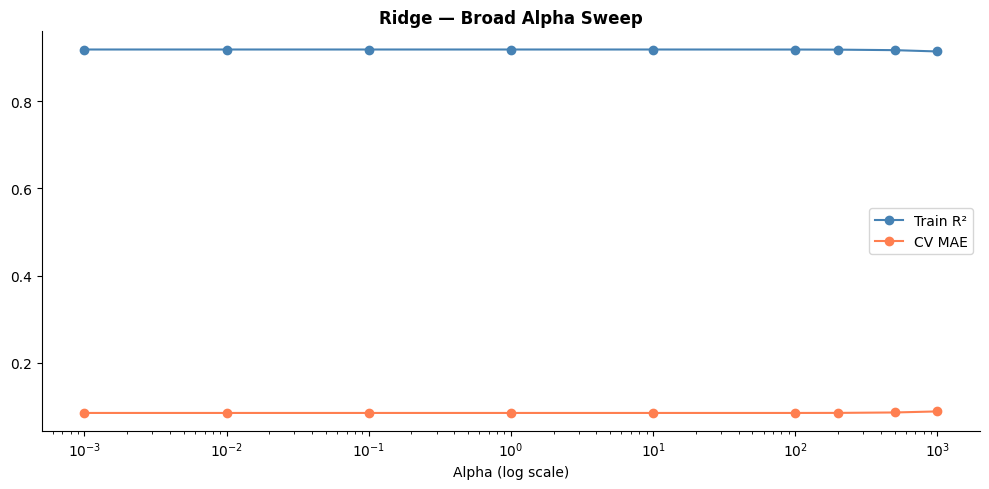

Best alpha (broad): 10
Best CV MAE       : 0.0851


In [31]:
## 5. Ridge Regression (LETS GOOO)

# 5.1 Broad alpha sweep
from sklearn.model_selection import cross_val_score

alphas_broad = [0.001, 0.01, 0.1, 1, 10, 100, 200, 500, 1000]

train_scores, test_scores = [], []

for alpha in alphas_broad:
    ridge = Ridge(alpha=alpha)
    # Cross-val score on train set (negative MAE)
    cv_score = cross_val_score(ridge, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_absolute_error').mean()
    ridge.fit(X_train_scaled, y_train)
    train_scores.append(ridge.score(X_train_scaled, y_train))
    test_scores.append(cv_score)

plt.figure(figsize=(10, 5))
plt.plot(alphas_broad, train_scores, 'o-', color='steelblue', label='Train R²')
plt.plot(alphas_broad, [-s for s in test_scores], 'o-', color='coral', label='CV MAE')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.title('Ridge — Broad Alpha Sweep', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_idx = np.argmin([-s for s in test_scores])
print(f'Best alpha (broad): {alphas_broad[best_idx]}')
print(f'Best CV MAE       : {-test_scores[best_idx]:.4f}')

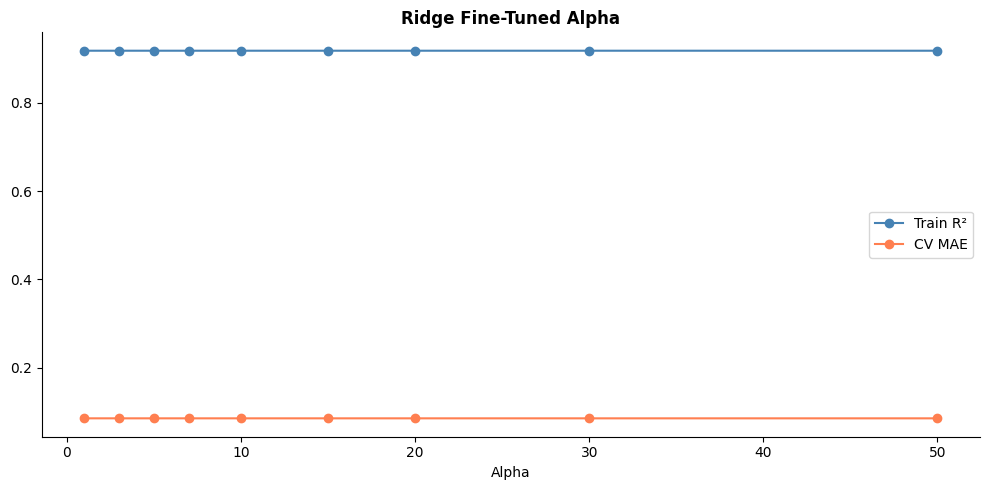

Best alpha (fine): 50
Best CV MAE      : 0.0851


In [32]:
# 5.2 Fine-tune around alpha = 10 🎯
alphas_fine = [1, 3, 5, 7, 10, 15, 20, 30, 50]

train_scores_f, test_scores_f = [], []

for alpha in alphas_fine:
    ridge = Ridge(alpha=alpha)
    cv_score = cross_val_score(ridge, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_absolute_error').mean()
    ridge.fit(X_train_scaled, y_train)
    train_scores_f.append(ridge.score(X_train_scaled, y_train))
    test_scores_f.append(cv_score)

plt.figure(figsize=(10, 5))
plt.plot(alphas_fine, train_scores_f, 'o-', color='steelblue', label='Train R²')
plt.plot(alphas_fine, [-s for s in test_scores_f], 'o-', color='coral', label='CV MAE')
plt.xlabel('Alpha')
plt.title('Ridge Fine-Tuned Alpha', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_idx_f = np.argmin([-s for s in test_scores_f])
best_alpha_ridge = alphas_fine[best_idx_f]
print(f'Best alpha (fine): {best_alpha_ridge}')
print(f'Best CV MAE      : {-test_scores_f[best_idx_f]:.4f}')

In [33]:
# 5.3 Fitting final Ridge model with best alpha
best_alpha_ridge = 10

ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge_final.predict(X_train_scaled)
y_pred_ridge_test  = ridge_final.predict(X_test_scaled)

print(f'Ridge (alpha={best_alpha_ridge})')
print('=' * 35)
ridge_train_r2, ridge_train_rmse, ridge_train_mae = evaluate(y_train, y_pred_ridge_train, 'Train')
print()
ridge_test_r2, ridge_test_rmse, ridge_test_mae   = evaluate(y_test,  y_pred_ridge_test,  'Test')
print()
print(f'R² gap: {ridge_train_r2 - ridge_test_r2:.4f}')

Ridge (alpha=10)
Train
  R²   : 0.9181
  RMSE : 0.1139
  MAE  : 0.0849

Test
  R²   : 0.9177
  RMSE : 0.1144
  MAE  : 0.0854

R² gap: 0.0004


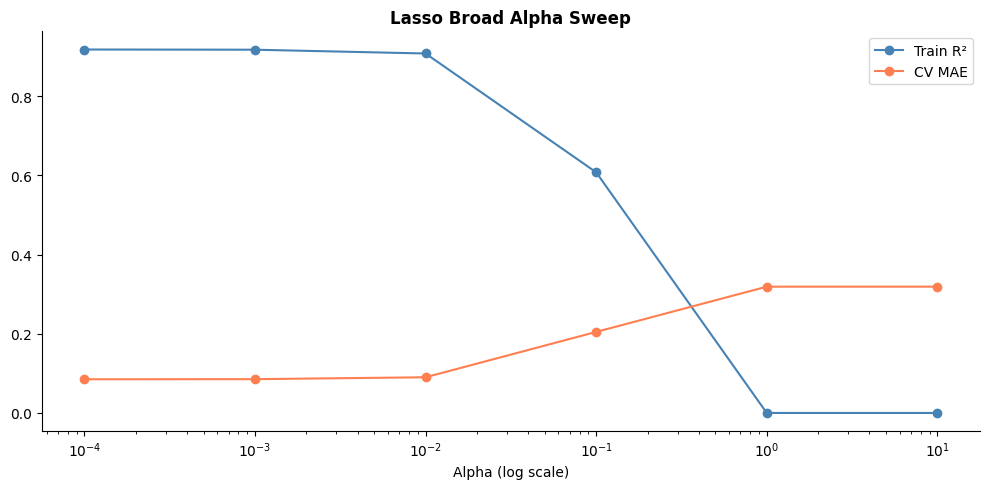

Best alpha (broad): 0.0001
Best CV MAE       : 0.0851


In [35]:
## 6. Lasso Regression

# 6.1  Broad alpha sweep
alphas_lasso_broad = [0.0001, 0.001, 0.01, 0.1, 1, 10]

train_scores_l, test_scores_l = [], []

for alpha in alphas_lasso_broad:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    cv_score = cross_val_score(lasso, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_absolute_error').mean()
    lasso.fit(X_train_scaled, y_train)
    train_scores_l.append(lasso.score(X_train_scaled, y_train))
    test_scores_l.append(cv_score)

plt.figure(figsize=(10, 5))
plt.plot(alphas_lasso_broad, train_scores_l, 'o-', color='steelblue', label='Train R²')
plt.plot(alphas_lasso_broad, [-s for s in test_scores_l], 'o-', color='coral', label='CV MAE')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.title('Lasso Broad Alpha Sweep', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_idx_l = np.argmin([-s for s in test_scores_l])
print(f'Best alpha (broad): {alphas_lasso_broad[best_idx_l]}')
print(f'Best CV MAE       : {-test_scores_l[best_idx_l]:.4f}')

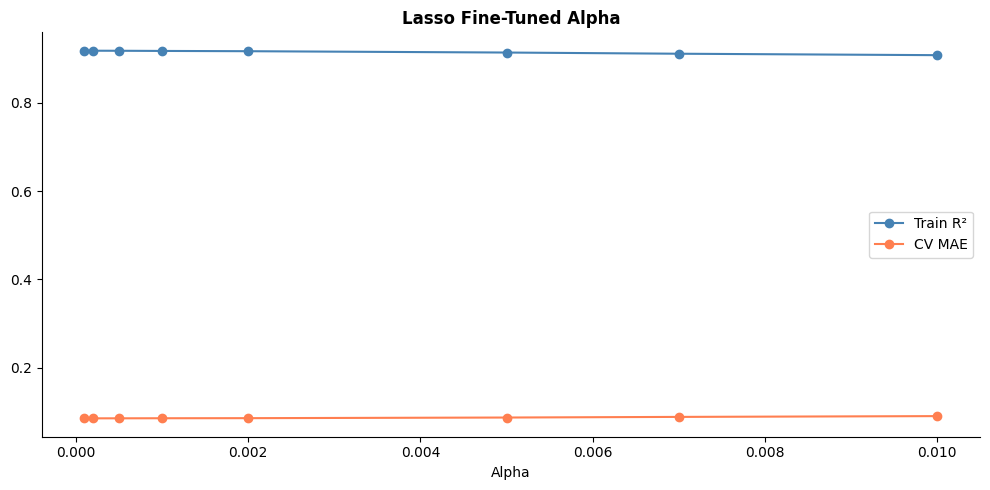

Best alpha (fine): 0.0001
Best CV MAE      : 0.0851


In [36]:
# 6.2  Fine-tune Lasso lets zoom into 0.0001 to 0.01
alphas_lasso_fine = [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.007, 0.01]

train_scores_lf, test_scores_lf = [], []

for alpha in alphas_lasso_fine:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    cv_score = cross_val_score(lasso, X_train_scaled, y_train,
                               cv=5, scoring='neg_mean_absolute_error').mean()
    lasso.fit(X_train_scaled, y_train)
    train_scores_lf.append(lasso.score(X_train_scaled, y_train))
    test_scores_lf.append(cv_score)

plt.figure(figsize=(10, 5))
plt.plot(alphas_lasso_fine, train_scores_lf, 'o-', color='steelblue', label='Train R²')
plt.plot(alphas_lasso_fine, [-s for s in test_scores_lf], 'o-', color='coral', label='CV MAE')
plt.xlabel('Alpha')
plt.title('Lasso Fine-Tuned Alpha', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_idx_lf = np.argmin([-s for s in test_scores_lf])
best_alpha_lasso = alphas_lasso_fine[best_idx_lf]
print(f'Best alpha (fine): {best_alpha_lasso}')
print(f'Best CV MAE      : {-test_scores_lf[best_idx_lf]:.4f}')

In [37]:
# 6.3 Fit final Lasso model
best_alpha_lasso = 0.0001

lasso_final = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso_final.predict(X_train_scaled)
y_pred_lasso_test  = lasso_final.predict(X_test_scaled)

print(f'Lasso (alpha={best_alpha_lasso})')
print('=' * 35)
lasso_train_r2, lasso_train_rmse, lasso_train_mae = evaluate(y_train, y_pred_lasso_train, 'Train')
print()
lasso_test_r2, lasso_test_rmse, lasso_test_mae   = evaluate(y_test,  y_pred_lasso_test,  'Test')
print()

# Check how many features were zeroed out
n_zero = (lasso_final.coef_ == 0).sum()
print(f'Features zeroed out by Lasso: {n_zero} / {len(lasso_final.coef_)}')

Lasso (alpha=0.0001)
Train
  R²   : 0.9181
  RMSE : 0.1139
  MAE  : 0.0849

Test
  R²   : 0.9178
  RMSE : 0.1144
  MAE  : 0.0853

Features zeroed out by Lasso: 1 / 33


In [38]:
# 6.4 Which feature did Lasso eliminate?
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Lasso_coef': lasso_final.coef_
})
print('Zeroed out feature:')
print(coef_df[coef_df['Lasso_coef'] == 0])

Zeroed out feature:
          Feature  Lasso_coef
23  body_type_Van         0.0


            Model  Train R²  Test R²  Test RMSE  Test MAE  R² Gap  Features Kept
Linear Regression    0.9181   0.9177     0.1144    0.0854  0.0004             33
     Ridge (α=10)    0.9181   0.9177     0.1144    0.0854  0.0004             33
 Lasso (α=0.0001)    0.9181   0.9178     0.1144    0.0853  0.0003             32


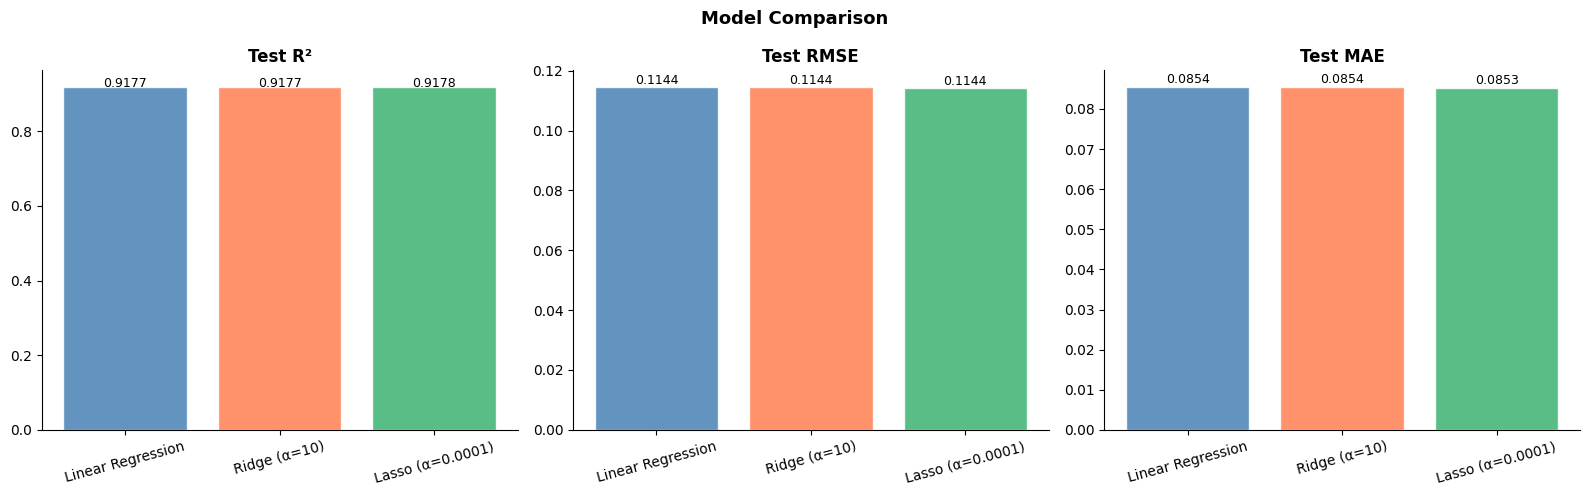

In [39]:
## 7. Model Comparison

# 7.1 Metrics summary table
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Ridge (α=10)', 'Lasso (α=0.0001)'],
    'Train R²':  [train_r2,       ridge_train_r2,  lasso_train_r2],
    'Test R²':   [test_r2,        ridge_test_r2,   lasso_test_r2],
    'Test RMSE': [test_rmse,      ridge_test_rmse, lasso_test_rmse],
    'Test MAE':  [test_mae,       ridge_test_mae,  lasso_test_mae],
    'R² Gap':    [train_r2-test_r2, ridge_train_r2-ridge_test_r2, lasso_train_r2-lasso_test_r2],
    'Features Kept': [33, 33, 32]
})

print(results.round(4).to_string(index=False))

# 7.2 Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = results['Model']
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric in zip(axes, ['Test R²', 'Test RMSE', 'Test MAE']):
    bars = ax.bar(models, results[metric], color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

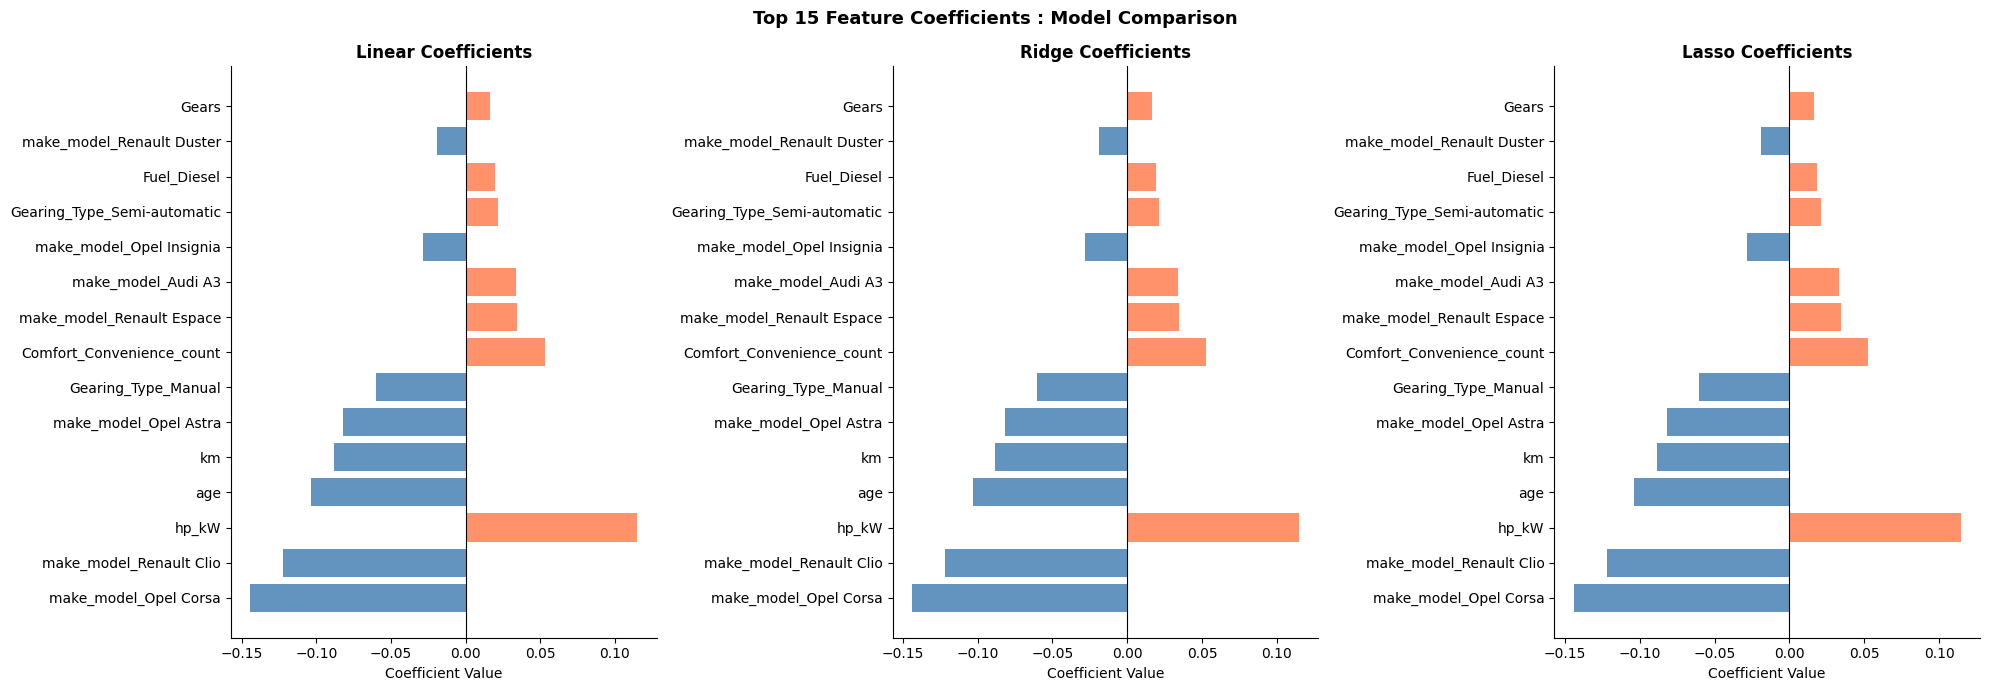

In [40]:
# 7.3 Coefficient comparison acros all 3 models
coef_compare = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear':  lr.coef_,
    'Ridge':   ridge_final.coef_,
    'Lasso':   lasso_final.coef_
}).sort_values('Linear', key=abs, ascending=False)

# Top 15 by absolute coefficient
top15 = coef_compare.head(15)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_map = {'Linear': 'steelblue', 'Ridge': 'coral', 'Lasso': 'mediumseagreen'}

for ax, model in zip(axes, ['Linear', 'Ridge', 'Lasso']):
    colors = ['coral' if v > 0 else 'steelblue' for v in top15[model]]
    ax.barh(top15['Feature'], top15[model], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{model} Coefficients', fontweight='bold')
    ax.set_xlabel('Coefficient Value')

plt.suptitle('Top 15 Feature Coefficients : Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Conclusion & Key Takeaways

**Did regularisation improve performance?**
No all three models achieved identical
R² = 0.918, RMSE = 0.114, MAE = 0.085.

The baseline linear regression was already well-generlised (R² gap = 0.0004),
leaving no overfitting for Ridge or Lasso to correct.

**What did regularisation reveal?**
- Ridge confirmed the model is stable as performance was flat across all alpha values,
  meaning multicollinearity was not severely distorting the coeficients
- Lasso eliminated only 1 feature (body_type_Van), confirming that 32 of 33
  features genuinely contribute to predicting car price

**Key factors influencing car price:**
- Engine power (hp_kW) is the single strongest predictor, more power = higher price
- Age and mileage (km) are the top depreciation drivers
- Brand matters as Opel Corsa and Renault Clio consistently price lower than
  Renault Espace and Audi A3
- Comfort features count (Comfort_Convenience_count) adds measurable price premium

**Is a linear model sufficient?**
For this dataset, yes as R² of 0.918 on unseen data is strong. The log transform on price was critical to achieving this.
A non-linear model (e.g. Random Forest, XGBoost) could potentially capture interactions between features like brand engine power, but the linear model already explains 92% of price variance.